In [1]:
# Базовые библиотеки для воспроизводимости, работы с данными и удобного вывода результатов.
import os
import re
import sys
import random
import subprocess
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import json

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def ensure_package(package_name: str, import_name: Optional[str] = None) -> None:
    """Пытается импортировать пакет и при необходимости установить его через pip."""
    target = import_name or package_name
    try:
        __import__(target)
    except Exception:
        print(f"Устанавливаем пакет: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


# Для retrieval-контура попробуем установить основные зависимости.
# Даже если sentence-transformers не поднимется, ноутбук сможет работать через fallback.
ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers", "sentence_transformers")


try:
    import faiss  # type: ignore
    FAISS_AVAILABLE = True
except Exception as e:
    FAISS_AVAILABLE = False
    print("FAISS недоступен, будет использован fallback на sklearn NearestNeighbors.")
    print("Причина:", repr(e))

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS available:", FAISS_AVAILABLE)

C:\Users\vnars\Desktop\AIE-course\pythonHW14\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NumPy: 2.4.3
Pandas: 3.0.2
FAISS available: True


In [2]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(RANDOM_STATE)

try:
    import torch

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)

Устройство для работы: cuda


In [3]:
# Переменные директорий
ROOT = Path(".")
DATA_DIR = ROOT / "data"
ARTIFACTS_DIR = ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
with open(DATA_DIR / "knowledge_base.json", "r", encoding="utf-8") as f:
    documents = json.load(f)

docs_df = pd.DataFrame(documents)
print("Размер корпуса:", len(docs_df))
display(docs_df[["doc_id", "title"]])
display(docs_df[:5])

Размер корпуса: 30


,doc_id,title
0,doc_01,Что такое эмбеддинги
1,doc_02,Зачем нужны эмбеддинги
2,doc_03,Косинусное сходство
3,doc_04,Евклидово расстояние
4,doc_05,Что такое FAISS
5,doc_06,Индекс в FAISS
6,doc_07,Flat индекс
7,doc_08,IVF индекс
8,doc_09,HNSW индекс
9,doc_10,Что такое retrieval


,doc_id,title,text
0,doc_01,Что такое эмбеддинги,Эмбеддинги — это плотные векторные представлен...
1,doc_02,Зачем нужны эмбеддинги,Эмбеддинги используются для поиска похожих тек...
2,doc_03,Косинусное сходство,Косинусное сходство измеряет угол между двумя ...
3,doc_04,Евклидово расстояние,Евклидово расстояние измеряет расстояние между...
4,doc_05,Что такое FAISS,FAISS — это библиотека от Meta для быстрого по...


## Модель эмбеддингов и fallback-стратегия

In [5]:
# Единый интерфейс для двух вариантов векторизации: dense embeddings и fallback.
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray()
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray()
        return vectors.astype("float32")


def build_embedding_backend(
    model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device: str = "cpu",
) -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(model_name=model_name, device=device)
        print("Используем полноценные dense embeddings.")
        print("Бэкэнд:", backend.backend_name)
        return backend
    except Exception as e:
        print("Не удалось загрузить sentence-transformers encoder.")
        print("Причина:", repr(e))
        print("Переключаемся на TF-IDF fallback. Ноутбук останется рабочим,")
        print("но это уже не полноценные dense embeddings.")
        return TfidfFallbackBackend()


embedder = build_embedding_backend(device=DEVICE)

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 6419.33it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


## Чанкинг документов

In [6]:
# Простая функция чанкинга по словам.
def chunk_text(text: str, chunk_size: int = 22, overlap: int = 5) -> List[str]:
    words = text.replace("\n", " ").split()

    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(words), step):
        chunk_words = words[start : start + chunk_size]
        if not chunk_words:
            continue

        chunks.append(" ".join(chunk_words))

        if start + chunk_size >= len(words):
            break

    return chunks


def build_chunks_dataframe(
    docs: List[Dict[str, str]],
    chunk_size: int = 22,
    overlap: int = 5,
) -> pd.DataFrame:
    rows = []

    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk in enumerate(chunks):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": chunk_id,
                    "chunk_text": chunk,
                    "n_words": len(chunk.split()),
                }
            )

    return pd.DataFrame(rows)


chunks_df = build_chunks_dataframe(documents, chunk_size=22, overlap=5)

print("Количество чанков:", len(chunks_df))
display(chunks_df.head(10))

Количество чанков: 34


,doc_id,title,chunk_id,chunk_text,n_words
0,doc_01,Что такое эмбеддинги,0,Эмбеддинги — это плотные векторные представлен...,22
1,doc_01,Что такое эмбеддинги,1,близости с помощью расстояний в векторном прос...,10
2,doc_02,Зачем нужны эмбеддинги,0,Эмбеддинги используются для поиска похожих тек...,22
3,doc_02,Зачем нужны эмбеддинги,1,"числам, с которыми удобно работать алгоритмиче...",6
4,doc_03,Косинусное сходство,0,Косинусное сходство измеряет угол между двумя ...,22
5,doc_03,Косинусное сходство,1,одна из самых популярных метрик в задачах поис...,10
6,doc_04,Евклидово расстояние,0,Евклидово расстояние измеряет расстояние между...,19
7,doc_05,Что такое FAISS,0,FAISS — это библиотека от Meta для быстрого по...,21
8,doc_06,Индекс в FAISS,0,"Индекс в FAISS — это структура данных, которая...",22
9,doc_06,Индекс в FAISS,1,Существует несколько типов индексов с разным б...,10


## Векторные представления чанков

In [7]:
# Строим векторные представления для всех чанков.
chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = embedder.fit_documents(chunk_texts)

print("Форма матрицы эмбеддингов:", chunk_embeddings.shape)

# Проверяем длины векторов.
# Если normalize_embeddings=True сработал корректно, все нормы должны быть ≈ 1.0.
# Это означает, что косинусное сходство далее можно считать через скалярное произведение.
vector_norms = np.linalg.norm(chunk_embeddings, axis=1)
print("Минимальная норма:", round(float(vector_norms.min()), 4))
print("Максимальная норма:", round(float(vector_norms.max()), 4))
print("Средняя норма:", round(float(vector_norms.mean()), 4))
print("→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.")

Форма матрицы эмбеддингов: (34, 384)
Минимальная норма: 1.0
Максимальная норма: 1.0
Средняя норма: 1.0
→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.


## Ручной расчёт сходства: запрос против всех чанков

In [8]:
# Считаем сходство запроса и всех чанков без FAISS.
query = "Как искать похожие фрагменты текста по векторам с помощью FAISS?"
# query = "Что такое индекс FAISS?"
query_vector = embedder.encode_queries([query])

# Для нормализованных векторов это эквивалент косинусного сходства.
manual_scores = (chunk_embeddings @ query_vector.T).ravel()

top_k = 5
top_indices = np.argsort(manual_scores)[::-1][:top_k]

manual_results_df = chunks_df.iloc[top_indices].copy()
manual_results_df["score"] = manual_scores[top_indices]
manual_results_df["score"] = manual_results_df["score"].round(4)
manual_results_df.insert(0, "rank", range(1, len(manual_results_df) + 1))

display(Markdown(f"**Запрос:** {query}"))
display(manual_results_df[["rank", "doc_id", "title", "chunk_id", "score", "chunk_text"]])

**Запрос:** Как искать похожие фрагменты текста по векторам с помощью FAISS?

,rank,doc_id,title,chunk_id,score,chunk_text
7,1,doc_05,Что такое FAISS,0,0.5764,FAISS — это библиотека от Meta для быстрого по...
2,2,doc_02,Зачем нужны эмбеддинги,0,0.5387,Эмбеддинги используются для поиска похожих тек...
4,3,doc_03,Косинусное сходство,0,0.5062,Косинусное сходство измеряет угол между двумя ...
8,4,doc_06,Индекс в FAISS,0,0.4794,"Индекс в FAISS — это структура данных, которая..."
0,5,doc_01,Что такое эмбеддинги,0,0.4753,Эмбеддинги — это плотные векторные представлен...


## Индекс `FAISS` для быстрого поиска

In [9]:
# Единая обёртка над FAISS и fallback-поиском.
class VectorSearchIndex:
    def __init__(self, dim: int) -> None:
        self.dim = dim
        self.backend_name = None
        self._faiss_index = None
        self._nn_index = None

        if FAISS_AVAILABLE:
            self._faiss_index = faiss.IndexFlatIP(dim)  # type: ignore[name-defined]
            self.backend_name = "FAISS IndexFlatIP"
        else:
            self._nn_index = NearestNeighbors(metric="cosine")
            self.backend_name = "sklearn NearestNeighbors fallback"

    def add(self, vectors: np.ndarray) -> None:
        vectors = vectors.astype("float32")

        if self._faiss_index is not None:
            self._faiss_index.add(vectors)
        else:
            self._nn_index.fit(vectors)

    def search(self, query_vectors: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        query_vectors = query_vectors.astype("float32")

        if self._faiss_index is not None:
            scores, indices = self._faiss_index.search(query_vectors, top_k)
            return scores, indices

        distances, indices = self._nn_index.kneighbors(query_vectors, n_neighbors=top_k)
        scores = 1.0 - distances
        return scores, indices


search_index = VectorSearchIndex(dim=chunk_embeddings.shape[1])
search_index.add(chunk_embeddings)

print("Индекс построен.")
print("Бэкэнд индекса:", search_index.backend_name)

Индекс построен.
Бэкэнд индекса: FAISS IndexFlatIP


In [10]:
# Удобная функция для поиска похожих чанков.
def search_similar_chunks(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vectors = embedder.encode_queries([query])
    scores, indices = search_index.search(query_vectors, top_k=top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": int(chunk_row["chunk_id"]),
                "score": round(float(score), 4),
                "chunk_text": chunk_row["chunk_text"],
            }
        )

    return pd.DataFrame(rows)

In [11]:
# Проверяем FAISS-поиск на первом запросе.
# Результаты должны совпасть с ручным расчётом из секции 6:
# тот же top-k, те же фрагменты, те же оценки сходства.
faiss_query = "Почему для similarity search нужен индекс по векторам?"
faiss_results_df = search_similar_chunks(faiss_query, top_k=5)

display(Markdown(f"### Запрос: `{faiss_query}`"))
display(faiss_results_df)

### Запрос: `Почему для similarity search нужен индекс по векторам?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_26,Similarity search,0,0.7407,"Similarity search — это поиск объектов, наибол..."
1,2,doc_03,Косинусное сходство,0,0.6439,Косинусное сходство измеряет угол между двумя ...
2,3,doc_05,Что такое FAISS,0,0.6331,FAISS — это библиотека от Meta для быстрого по...
3,4,doc_06,Индекс в FAISS,0,0.5744,"Индекс в FAISS — это структура данных, которая..."
4,5,doc_27,Dense retrieval,0,0.5596,Dense retrieval использует эмбеддинги для поис...


## Пакетный запуск нескольких запросов

In [12]:
# Проверяем retrieval на нескольких запросах.
example_queries = [
    "Что такое эмбеддинги текстов и зачем они нужны?",
    "Как работает FAISS при поиске ближайших соседей?",
    "Зачем делить длинные документы на чанки?",
    "Почему качество RAG зависит от retrieval?",
    "Как понять, что поиск по базе знаний работает плохо?",
]

for current_query in example_queries:
    display(Markdown(f"### Запрос: `{current_query}`"))
    display(search_similar_chunks(current_query, top_k=3))

### Запрос: `Что такое эмбеддинги текстов и зачем они нужны?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_01,Что такое эмбеддинги,0,0.6762,Эмбеддинги — это плотные векторные представлен...
1,2,doc_02,Зачем нужны эмбеддинги,0,0.5143,Эмбеддинги используются для поиска похожих тек...
2,3,doc_15,Чанкинг текста,0,0.5101,Чанкинг — это разбиение документов на небольши...


### Запрос: `Как работает FAISS при поиске ближайших соседей?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_05,Что такое FAISS,0,0.5011,FAISS — это библиотека от Meta для быстрого по...
1,2,doc_17,Overlap чанков,0,0.4503,Overlap — это пересечение между соседними чанк...
2,3,doc_09,HNSW индекс,0,0.4326,HNSW — это графовый индекс для approximate nea...


### Запрос: `Зачем делить длинные документы на чанки?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_16,Размер чанка,0,0.5864,Размер чанка определяет длину текстового фрагм...
1,2,doc_15,Чанкинг текста,0,0.3781,Чанкинг — это разбиение документов на небольши...
2,3,doc_23,Knowledge base,0,0.3358,"База знаний — это набор документов, по которым..."


### Запрос: `Почему качество RAG зависит от retrieval?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_18,Что такое RAG,0,0.7141,"RAG — это подход, объединяющий retrieval и ген..."
1,2,doc_10,Что такое retrieval,0,0.6779,Retrieval — это процесс поиска релевантных док...
2,3,doc_27,Dense retrieval,0,0.5983,Dense retrieval использует эмбеддинги для поис...


### Запрос: `Как понять, что поиск по базе знаний работает плохо?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_23,Knowledge base,0,0.5526,"База знаний — это набор документов, по которым..."
1,2,doc_30,Top-k выбор,0,0.4520,Выбор параметра top-k влияет на баланс между п...
2,3,doc_16,Размер чанка,0,0.4448,Размер чанка определяет длину текстового фрагм...


## Контрольные запросы

In [13]:
benchmark_queries: List[Dict[str, object]] = [
    {
        "query_id": "q01",
        "query": "Что такое эмбеддинги и зачем они нужны?",
        "relevant_doc_ids": ["doc_01", "doc_02"],
    },
    {
        "query_id": "q02",
        "query": "Как измеряется сходство между текстами в векторном пространстве?",
        "relevant_doc_ids": ["doc_03", "doc_04"],
    },
    {
        "query_id": "q03",
        "query": "Что такое FAISS и для чего он используется?",
        "relevant_doc_ids": ["doc_05"],
    },
    {
        "query_id": "q04",
        "query": "Какие бывают индексы в FAISS и чем они отличаются?",
        "relevant_doc_ids": ["doc_06", "doc_07", "doc_08", "doc_09"],
    },
    {
        "query_id": "q05",
        "query": "Что такое retrieval и как работает top-k поиск?",
        "relevant_doc_ids": ["doc_10", "doc_11"],
    },
    {
        "query_id": "q06",
        "query": "Какие метрики используются для оценки retrieval?",
        "relevant_doc_ids": ["doc_12", "doc_13", "doc_14"],
    },
    {
        "query_id": "q07",
        "query": "Что такое чанкинг и зачем нужен overlap?",
        "relevant_doc_ids": ["doc_15", "doc_17"],
    },
    {
        "query_id": "q08",
        "query": "Что такое RAG и из каких этапов состоит его pipeline?",
        "relevant_doc_ids": ["doc_18", "doc_19", "doc_20"],
    },
]

benchmark_df = pd.DataFrame(benchmark_queries)
display(benchmark_df)

,query_id,query,relevant_doc_ids
0,q01,Что такое эмбеддинги и зачем они нужны?,"[doc_01, doc_02]"
1,q02,Как измеряется сходство между текстами в векто...,"[doc_03, doc_04]"
2,q03,Что такое FAISS и для чего он используется?,[doc_05]
3,q04,Какие бывают индексы в FAISS и чем они отличаю...,"[doc_06, doc_07, doc_08, doc_09]"
4,q05,Что такое retrieval и как работает top-k поиск?,"[doc_10, doc_11]"
5,q06,Какие метрики используются для оценки retrieval?,"[doc_12, doc_13, doc_14]"
6,q07,Что такое чанкинг и зачем нужен overlap?,"[doc_15, doc_17]"
7,q08,Что такое RAG и из каких этапов состоит его pi...,"[doc_18, doc_19, doc_20]"


## Компактный retrieval-конвейер

In [14]:
# В этом разделе собираем self-contained реализацию:
# чанкинг -> векторизация -> индекс -> поиск -> оценка.

def chunk_text(text: str, chunk_size: int = 40, overlap: int = 10) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на fallback.")
        print("Причина:", repr(e))
        return TfidfBackend()


def build_chunks(
    docs: List[Dict[str, str]],
    chunk_size: int,
    overlap: int,
) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for doc in docs:
        parts = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk_text_value in enumerate(parts):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx}",
                    "chunk_idx": chunk_idx,
                    "chunk_text": chunk_text_value,
                }
            )
    return rows

def choose_backend(device: str = "cpu") -> EmbeddingBackend:
    # Опциональная попытка dense backend.
    if SENTENCE_TRANSFORMERS_READY:
        try:
            return SentenceTransformersBackend(
                model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                device=device,
            )
        except Exception as e:
            print("Dense backend недоступен, переходим к TF-IDF.")
            print("Причина:", repr(e))
    return TfidfBackend()

@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 40,
    overlap: int = 10,
    device: str = "cpu",
) -> RetrievalArtifacts:
    chunks = build_chunks(docs, chunk_size=chunk_size, overlap=overlap)
    chunks_df = pd.DataFrame(chunks)

    backend = select_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    if not FAISS_AVAILABLE:
        raise RuntimeError("FAISS недоступен. Для этого ноутбука ожидается установленный faiss-cpu.")

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )


def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)


def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)

## Базовый retrieval и контрольные примеры

In [15]:
# Собираем baseline-конфигурацию retriever.
baseline_chunk_size = 28
baseline_overlap = 8

artifacts = build_retriever(
    documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

# Посмотрим несколько контрольных запросов вручную.
sample_queries = [
    "Что такое эмбеддинги?",
    "Как оценивать retrieval?",
    "Зачем переиндексировать базу знаний после обновления?",
]

for query in sample_queries:
    display(Markdown(f"### Запрос: {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 14201.29it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 30


,doc_id,title,chunk_id,chunk_idx,chunk_text
0,doc_01,Что такое эмбеддинги,doc_01_chunk_0,0,Эмбеддинги — это плотные векторные представлен...
1,doc_02,Зачем нужны эмбеддинги,doc_02_chunk_0,0,Эмбеддинги используются для поиска похожих тек...
2,doc_03,Косинусное сходство,doc_03_chunk_0,0,Косинусное сходство измеряет угол между двумя ...
3,doc_04,Евклидово расстояние,doc_04_chunk_0,0,Евклидово расстояние измеряет расстояние между...
4,doc_05,Что такое FAISS,doc_05_chunk_0,0,FAISS — это библиотека от Meta для быстрого по...


### Запрос: Что такое эмбеддинги?

,rank,score,doc_id,title,chunk_text
0,1,0.448474,doc_01,Что такое эмбеддинги,Эмбеддинги — это плотные векторные представлен...
1,2,0.324693,doc_22,Hallucinations,"Галлюцинации — это случаи, когда модель генери..."
2,3,0.310683,doc_18,Что такое RAG,"RAG — это подход, объединяющий retrieval и ген..."


### Запрос: Как оценивать retrieval?

,rank,score,doc_id,title,chunk_text
0,1,0.750331,doc_10,Что такое retrieval,Retrieval — это процесс поиска релевантных док...
1,2,0.684721,doc_27,Dense retrieval,Dense retrieval использует эмбеддинги для поис...
2,3,0.650486,doc_13,Что такое recall@k,"Recall@k измеряет долю релевантных документов,..."


### Запрос: Зачем переиндексировать базу знаний после обновления?

,rank,score,doc_id,title,chunk_text
0,1,0.740529,doc_24,Обновление базы знаний,Обновление базы знаний включает добавление нов...
1,2,0.641916,doc_25,Переиндексация,Переиндексация — это процесс пересоздания инде...
2,3,0.504367,doc_30,Top-k выбор,Выбор параметра top-k влияет на баланс между п...


## Простая оценка качества извлечения

In [16]:
# Прогоняем весь benchmark и считаем метрики для baseline-конфигурации.
baseline_eval_k3 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "value": [
            baseline_eval_k3["hit@3"].mean(),
            baseline_eval_k3["recall@3"].mean(),
            baseline_eval_k3["MRR@3"].mean(),
        ],
    }
)
display(summary_k3)

table_retrieval_eval = pd.DataFrame(
    {
        "query": baseline_eval_k3["query"],
        "expected_source": baseline_eval_k3["relevant_doc_ids"],
        "retrieved_sources": baseline_eval_k3["predicted_doc_ids"],
        "hit_at_k": baseline_eval_k3["hit@3"],
    }
)

# display(table_retrieval_eval)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Что такое эмбеддинги и зачем они нужны?,"doc_01, doc_02","doc_01, doc_22, doc_23",1,0.500000,1.0,1
1,q02,Как измеряется сходство между текстами в векто...,"doc_03, doc_04","doc_03, doc_01, doc_04",1,1.000000,1.0,1
2,q03,Что такое FAISS и для чего он используется?,doc_05,"doc_06, doc_05, doc_23",1,1.000000,0.5,2
3,q04,Какие бывают индексы в FAISS и чем они отличаю...,"doc_06, doc_07, doc_08, doc_09","doc_06, doc_14, doc_07",1,0.500000,1.0,1
4,q05,Что такое retrieval и как работает top-k поиск?,"doc_10, doc_11","doc_11, doc_27, doc_10",1,1.000000,1.0,1
5,q06,Какие метрики используются для оценки retrieval?,"doc_12, doc_13, doc_14","doc_13, doc_14, doc_02",1,0.666667,1.0,1
6,q07,Что такое чанкинг и зачем нужен overlap?,"doc_15, doc_17","doc_17, doc_03, doc_15",1,1.000000,1.0,1
7,q08,Что такое RAG и из каких этапов состоит его pi...,"doc_18, doc_19, doc_20","doc_19, doc_18, doc_10",1,0.666667,1.0,1


,metric,value
0,mean_hit@3,1.000000
1,mean_recall@3,0.791667
2,mean_MRR@3,0.937500


## Сравнение по chunk_size

In [17]:
# Сравниваем несколько конфигураций чанкинга.
chunk_configs = [
    {"chunk_size": 15, "overlap": 4},
    # {"chunk_size": 28, "overlap": 8},
    # {"chunk_size": 40, "overlap": 10},
    {"chunk_size": 60, "overlap": 4},
]

chunk_experiments = []

for cfg in chunk_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg["chunk_size"],
        overlap=cfg["overlap"],
        device=DEVICE,
    )
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=exp_artifacts, top_k=3)

    chunk_experiments.append(
        {
            "chunk_size": cfg["chunk_size"],
            "overlap": cfg["overlap"],
            "num_chunks": len(exp_artifacts.chunks_df),
            "backend_name": exp_artifacts.backend_name,
            "mean_hit@3": eval_df["hit@3"].mean(),
            "mean_recall@3": eval_df["recall@3"].mean(),
            "mean_MRR@3": eval_df["MRR@3"].mean(),
        }
    )

chunk_experiments_df = pd.DataFrame(chunk_experiments).sort_values(
    by=["mean_hit@3", "mean_MRR@3", "num_chunks"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(chunk_experiments_df)

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 11055.48it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 6858.56it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,chunk_size,overlap,num_chunks,backend_name,mean_hit@3,mean_recall@3,mean_MRR@3
0,60,4,30,SentenceTransformer: sentence-transformers/par...,1.000,0.791667,0.9375
1,15,4,54,SentenceTransformer: sentence-transformers/par...,0.875,0.572917,0.7500


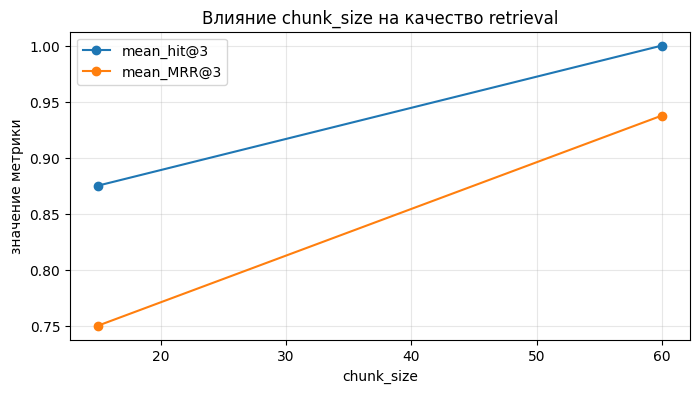

In [18]:
# Небольшая визуализация: как меняется качество при разных конфигурациях чанкинга.
# chunk_experiments_df отсортирован по качеству; для графика обязательно сортируем по chunk_size,
# иначе ось X будет в произвольном порядке и линии пересекутся.
plot_df = chunk_experiments_df.sort_values("chunk_size").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["chunk_size"], plot_df["mean_hit@3"], marker="o", label="mean_hit@3")
plt.plot(plot_df["chunk_size"], plot_df["mean_MRR@3"], marker="o", label="mean_MRR@3")
plt.xlabel("chunk_size")
plt.ylabel("значение метрики")
plt.title("Влияние chunk_size на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Обновляем базу знаний

In [19]:
# Представим, что база знаний пополнилась новыми документами.
new_documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_31",
        "title": "Реранжирование результатов retrieval",
        "text": (
            "После первичного поиска можно применить реранжирование: сначала retriever достаёт несколько "
            "кандидатов, а затем более точная модель пересортировывает их по полезности. "
            "Это особенно полезно, когда базовый retrieval находит тематически близкие, но не самые точные фрагменты."
        ),
    },
    {
        "doc_id": "doc_32",
        "title": "Гибридный поиск",
        "text": (
            "Гибридный поиск объединяет dense retrieval и классический лексический поиск. "
            "Он помогает в случаях, когда часть запросов требует смыслового соответствия, "
            "а часть – точного совпадения терминов, названий или аббревиатур."
        ),
    },
]

updated_documents = documents + new_documents

display(pd.DataFrame(new_documents)[["doc_id", "title"]])

new_queries = [
    "Зачем нужен реранжировщик после первичного retrieval?",
    "Когда полезен гибридный поиск?",
]

display(Markdown("### Как baseline-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

,doc_id,title
0,doc_31,Реранжирование результатов retrieval
1,doc_32,Гибридный поиск


### Как baseline-база отвечает на новые запросы

**Запрос:** Зачем нужен реранжировщик после первичного retrieval?

,rank,score,doc_id,title,chunk_text
0,1,0.599313,doc_27,Dense retrieval,Dense retrieval использует эмбеддинги для поис...
1,2,0.587744,doc_10,Что такое retrieval,Retrieval — это процесс поиска релевантных док...
2,3,0.505282,doc_11,Top-k retrieval,Top-k retrieval означает выбор k наиболее реле...


**Запрос:** Когда полезен гибридный поиск?

,rank,score,doc_id,title,chunk_text
0,1,0.518451,doc_26,Similarity search,"Similarity search — это поиск объектов, наибол..."
1,2,0.498300,doc_05,Что такое FAISS,FAISS — это библиотека от Meta для быстрого по...
2,3,0.452041,doc_27,Dense retrieval,Dense retrieval использует эмбеддинги для поис...


In [20]:
# Переиндексируем корпус уже с новыми документами.
updated_artifacts = build_retriever(
    updated_documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

# Расширяем benchmark новыми запросами.
extended_benchmark_queries = benchmark_queries + [
    {
        "query_id": "q07",
        "query": "Зачем нужен реранжировщик после первичного retrieval?",
        "relevant_doc_ids": ["doc_09"],
    },
    {
        "query_id": "q08",
        "query": "Когда полезен гибридный поиск?",
        "relevant_doc_ids": ["doc_10"],
    },
]

before_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=updated_artifacts, top_k=3)

table_retrieval_before_after_update = pd.DataFrame(
    {
        "query": before_update_eval["query"],
        "before_retrieved_sources": before_update_eval["predicted_doc_ids"],
        "after_retrieved_sources": after_update_eval["predicted_doc_ids"],
        "changed": before_update_eval["predicted_doc_ids"] != after_update_eval["predicted_doc_ids"],
    }
)


comparison_df = before_update_eval.merge(
    after_update_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)

display(comparison_df)

summary_comparison_df = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "before_update": [
            before_update_eval["hit@3"].mean(),
            before_update_eval["recall@3"].mean(),
            before_update_eval["MRR@3"].mean(),
        ],
        "after_update": [
            after_update_eval["hit@3"].mean(),
            after_update_eval["recall@3"].mean(),
            after_update_eval["MRR@3"].mean(),
        ],
    }
)
summary_comparison_df["delta"] = summary_comparison_df["after_update"] - summary_comparison_df["before_update"]
display(summary_comparison_df)

display(Markdown("### Как updated-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=updated_artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 15308.52it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,query_id,query,relevant_doc_ids,predicted_doc_ids_before,hit@3_before,recall@3_before,MRR@3_before,first_relevant_rank_before,predicted_doc_ids_after,hit@3_after,recall@3_after,MRR@3_after,first_relevant_rank_after
0,q01,Что такое эмбеддинги и зачем они нужны?,"doc_01, doc_02","doc_01, doc_22, doc_23",1,0.500000,1.0,1.0,"doc_01, doc_22, doc_23",1,0.500000,1.0,1.0
1,q02,Как измеряется сходство между текстами в векто...,"doc_03, doc_04","doc_03, doc_01, doc_04",1,1.000000,1.0,1.0,"doc_03, doc_01, doc_04",1,1.000000,1.0,1.0
2,q03,Что такое FAISS и для чего он используется?,doc_05,"doc_06, doc_05, doc_23",1,1.000000,0.5,2.0,"doc_06, doc_05, doc_23",1,1.000000,0.5,2.0
3,q04,Какие бывают индексы в FAISS и чем они отличаю...,"doc_06, doc_07, doc_08, doc_09","doc_06, doc_14, doc_07",1,0.500000,1.0,1.0,"doc_06, doc_14, doc_07",1,0.500000,1.0,1.0
4,q05,Что такое retrieval и как работает top-k поиск?,"doc_10, doc_11","doc_11, doc_27, doc_10",1,1.000000,1.0,1.0,"doc_11, doc_27, doc_10",1,1.000000,1.0,1.0
5,q06,Какие метрики используются для оценки retrieval?,"doc_12, doc_13, doc_14","doc_13, doc_14, doc_02",1,0.666667,1.0,1.0,"doc_13, doc_14, doc_02",1,0.666667,1.0,1.0
6,q07,Что такое чанкинг и зачем нужен overlap?,"doc_15, doc_17","doc_17, doc_03, doc_15",1,1.000000,1.0,1.0,"doc_17, doc_03, doc_15",1,1.000000,1.0,1.0
7,q08,Что такое RAG и из каких этапов состоит его pi...,"doc_18, doc_19, doc_20","doc_19, doc_18, doc_10",1,0.666667,1.0,1.0,"doc_19, doc_18, doc_10",1,0.666667,1.0,1.0
8,q07,Зачем нужен реранжировщик после первичного ret...,doc_09,"doc_27, doc_10, doc_11",0,0.000000,0.0,NaN,"doc_31, doc_27",0,0.000000,0.0,NaN
9,q08,Когда полезен гибридный поиск?,doc_10,"doc_26, doc_05, doc_27",0,0.000000,0.0,NaN,"doc_32, doc_31, doc_26",0,0.000000,0.0,NaN


,metric,before_update,after_update,delta
0,mean_hit@3,0.800000,0.800000,0.0
1,mean_recall@3,0.633333,0.633333,0.0
2,mean_MRR@3,0.750000,0.750000,0.0


### Как updated-база отвечает на новые запросы

**Запрос:** Зачем нужен реранжировщик после первичного retrieval?

,rank,score,doc_id,title,chunk_text
0,1,0.661293,doc_31,Реранжирование результатов retrieval,После первичного поиска можно применить реранж...
1,2,0.635392,doc_31,Реранжирование результатов retrieval,"Это особенно полезно, когда базовый retrieval ..."
2,3,0.599313,doc_27,Dense retrieval,Dense retrieval использует эмбеддинги для поис...


**Запрос:** Когда полезен гибридный поиск?

,rank,score,doc_id,title,chunk_text
0,1,0.674102,doc_32,Гибридный поиск,Гибридный поиск объединяет dense retrieval и к...
1,2,0.593860,doc_31,Реранжирование результатов retrieval,После первичного поиска можно применить реранж...
2,3,0.518451,doc_26,Similarity search,"Similarity search — это поиск объектов, наибол..."


In [21]:
artifacts = build_retriever(
    documents,
    chunk_size=24,
    overlap=6,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 10473.13it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 33


,doc_id,title,chunk_id,chunk_idx,chunk_text
0,doc_01,Что такое эмбеддинги,doc_01_chunk_0,0,Эмбеддинги — это плотные векторные представлен...
1,doc_01,Что такое эмбеддинги,doc_01_chunk_1,1,"с помощью расстояний в векторном пространстве,..."
2,doc_02,Зачем нужны эмбеддинги,doc_02_chunk_0,0,Эмбеддинги используются для поиска похожих тек...
3,doc_03,Косинусное сходство,doc_03_chunk_0,0,Косинусное сходство измеряет угол между двумя ...
4,doc_03,Косинусное сходство,doc_03_chunk_1,1,из самых популярных метрик в задачах поиска по...


In [22]:
sample_queries = [
    "Почему нужен чанкинг в RAG?",
    "Как оценивают качество retrieval?",
    "Зачем переиндексировать базу знаний?",
]

for query in sample_queries:
    display(Markdown(f"### Запрос: {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3))

### Запрос: Почему нужен чанкинг в RAG?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.443922,doc_18,Что такое RAG,doc_18_chunk_0,"RAG — это подход, объединяющий retrieval и ген..."
1,2,0.391031,doc_19,Pipeline RAG,doc_19_chunk_0,RAG pipeline включает этапы: получение запроса...
2,3,0.278637,doc_15,Чанкинг текста,doc_15_chunk_0,Чанкинг — это разбиение документов на небольши...


### Запрос: Как оценивают качество retrieval?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.701270,doc_10,Что такое retrieval,doc_10_chunk_0,Retrieval — это процесс поиска релевантных док...
1,2,0.632182,doc_27,Dense retrieval,doc_27_chunk_0,Dense retrieval использует эмбеддинги для поис...
2,3,0.616668,doc_13,Что такое recall@k,doc_13_chunk_0,"Recall@k измеряет долю релевантных документов,..."


### Запрос: Зачем переиндексировать базу знаний?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.613265,doc_24,Обновление базы знаний,doc_24_chunk_0,Обновление базы знаний включает добавление нов...
1,2,0.553707,doc_30,Top-k выбор,doc_30_chunk_0,Выбор параметра top-k влияет на баланс между п...
2,3,0.551783,doc_25,Переиндексация,doc_25_chunk_0,Переиндексация — это процесс пересоздания инде...


## Baseline без retrieval

In [23]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]


def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc["title"] + ". " + doc["text"] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)

    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]

    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)

    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc["text"], top_n=2)

    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось уверенно извлечь ответ без retrieval по чанкам. "
            "Система выбрала наиболее похожий документ целиком."
        )

    return {
        "answer": answer,
        "selected_doc_id": best_doc["doc_id"],
        "selected_title": best_doc["title"],
        "score": float(scores[best_idx]),
    }

In [24]:
baseline_example = answer_without_retrieval(
    "Почему нужен чанкинг в RAG?",
    documents,
)

display(pd.DataFrame([baseline_example]))

,answer,selected_doc_id,selected_title,score
0,Чанкинг — это разбиение документов на небольши...,doc_15,Чанкинг текста,0.111118


## Формируем контекст для mini-RAG

In [25]:
def build_context_from_retrieval(query: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved

In [26]:
query = "Зачем после обновления базы знаний нужна переиндексация?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)

### Запрос: Зачем после обновления базы знаний нужна переиндексация?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.709310,doc_24,Обновление базы знаний,doc_24_chunk_0,Обновление базы знаний включает добавление нов...
1,2,0.639476,doc_25,Переиндексация,doc_25_chunk_0,Переиндексация — это процесс пересоздания инде...
2,3,0.535922,doc_30,Top-k выбор,doc_30_chunk_0,Выбор параметра top-k влияет на баланс между п...


[Источник: doc_24 | Обновление базы знаний | score=0.7093]
Обновление базы знаний включает добавление новых документов и переиндексацию, чтобы retrieval учитывал изменения.

[Источник: doc_25 | Переиндексация | score=0.6395]
Переиндексация — это процесс пересоздания индекса после изменения данных. Она необходима для корректного поиска.

[Источник: doc_30 | Top-k выбор | score=0.5359]
Выбор параметра top-k влияет на баланс между полнотой и точностью. Большой k увеличивает recall, но может ухудшить качество контекста.


## Генератор ответа по найденному контексту

In [27]:
def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Убираем технические строки источников из ранжирования, но не из общего контекста.
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)

## Полный mini-RAG-пайплайн

In [28]:
def mini_rag_answer(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }

In [29]:
query = "Зачем после обновления базы знаний нужна переиндексация?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)

### Запрос: Зачем после обновления базы знаний нужна переиндексация?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.709310,doc_24,Обновление базы знаний,doc_24_chunk_0,Обновление базы знаний включает добавление нов...
1,2,0.639476,doc_25,Переиндексация,doc_25_chunk_0,Переиндексация — это процесс пересоздания инде...
2,3,0.535922,doc_30,Top-k выбор,doc_30_chunk_0,Выбор параметра top-k влияет на баланс между п...


[Источник: doc_24 | Обновление базы знаний | score=0.7093]
Обновление базы знаний включает добавление новых документов и переиндексацию, чтобы retrieval учитывал изменения.

[Источник: doc_25 | Переиндексация | score=0.6395]
Переиндексация — это процесс пересоздания индекса после изменения данных. Она необходима для корректного поиска.

[Источник: doc_30 | Top-k выбор | score=0.5359]
Выбор параметра top-k влияет на баланс между полнотой и точностью. Большой k увеличивает recall, но может ухудшить качество контекста.


## Сравнение: без retrieval vs с retrieval

In [30]:
comparison_queries = [
    "Почему overlap полезен при чанкинге?",
    "Как оценивают качество retrieval?",
    "Что делать после обновления базы знаний?",
    "Когда полезен гибридный поиск?",
    "Как RAG связан с галлюцинациями?",
]

comparison_rows = []

for query in comparison_queries:
    baseline = answer_without_retrieval(query, documents)
    rag = mini_rag_answer(query, artifacts=artifacts, top_k=3)

    comparison_rows.append(
        {
            "query": query,
            "baseline_doc_id": baseline["selected_doc_id"],
            "baseline_score": baseline["score"],
            "baseline_answer": baseline["answer"],
            "rag_answer": rag["answer"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,query,baseline_doc_id,baseline_score,baseline_answer,rag_answer
0,Почему overlap полезен при чанкинге?,doc_17,0.099764,Overlap — это пересечение между соседними чанк...,Overlap — это пересечение между соседними чанк...
1,Как оценивают качество retrieval?,doc_04,0.050975,В задачах поиска по эмбеддингам используется к...,Dense retrieval использует эмбеддинги для поис...
2,Что делать после обновления базы знаний?,doc_24,0.251588,Обновление базы знаний включает добавление нов...,Обновление базы знаний включает добавление нов...
3,Когда полезен гибридный поиск?,doc_22,0.056870,"Галлюцинации — это случаи, когда модель генери...",В контексте NLP используется поиск по эмбеддин...
4,Как RAG связан с галлюцинациями?,doc_19,0.069010,RAG pipeline включает этапы: получение запроса...,"RAG — это подход, объединяющий retrieval и ген..."


In [31]:
for _, row in comparison_df.iterrows():
    display(Markdown(f"### Вопрос: {row['query']}"))
    display(Markdown(f"**Baseline без retrieval:** {row['baseline_answer']}"))
    display(Markdown(f"**Mini-RAG:** {row['rag_answer']}"))

### Вопрос: Почему overlap полезен при чанкинге?

**Baseline без retrieval:** Overlap — это пересечение между соседними чанками.

**Mini-RAG:** Overlap — это пересечение между соседними чанками.

### Вопрос: Как оценивают качество retrieval?

**Baseline без retrieval:** В задачах поиска по эмбеддингам используется как альтернатива косинусному сходству.

...

**Baseline без retrieval:** Галлюцинации — это случаи, когда модель генерирует неверную информацию.

**Mini-RAG:** В контексте NLP используется поиск по эмбеддингам. Similarity search — это поиск объектов, наиболее похожих на запрос.

### Вопрос: Как RAG связан с галлюцинациями?

**Baseline без retrieval:** RAG pipeline включает этапы: получение запроса, поиск документов, формирование контекста и генерация ответа.

**Mini-RAG:** RAG — это подход, объединяющий retrieval и генерацию. RAG помогает снизить их за счёт использования реальных данных.

## Возвращаем ответ вместе с источниками

In [32]:
query = "Зачем нужен реранжировщик после первичного retrieval?"
rag_result = mini_rag_answer(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Вопрос: {query}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown(f"**Источник:** {rag_result["sources"]["doc_id"][0]}"))
# display(rag_result["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])

### Вопрос: Зачем нужен реранжировщик после первичного retrieval?

**Ответ:** Dense retrieval использует эмбеддинги для поиска. Top-k retrieval означает выбор k наиболее релевантных документов по запросу.

**Источник:** doc_27

## Сохраняем артефакты

In [33]:
# retrieval_eval.csv - таблица с результатами retrieval на контрольных запросах
table_retrieval_eval.to_csv(ARTIFACTS_DIR / "retrieval_eval.csv", index=False)

# retrieval_before_after_update.csv - сравнение retrieval до и после обновления базы знаний
table_retrieval_before_after_update.to_csv(ARTIFACTS_DIR / "retrieval_before_after_update.csv", index=False)

# rag_examples.csv - таблица с примерами работы mini-RAG
rag_examples = []
for query in comparison_queries:
    result = mini_rag_answer(query, artifacts=artifacts, top_k=3)
    rag_examples.append({
        "question": query,
        "answer": result["answer"],
        "retrieved_sources": ",".join(result["sources"]["doc_id"]),
    })
rag_df = pd.DataFrame(rag_examples)
rag_df.to_csv(ARTIFACTS_DIR / "rag_examples.csv", index=False)